In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,confusion_matrix
import matplotlib.pyplot as plt



In [2]:
#loading data

iris = load_iris()
x = iris.data
y = iris.target

In [45]:
data = pd.DataFrame(iris.data, columns = iris.feature_names)

data["target"] = iris.target
data["target_name"] = data["target"].apply(lambda x: iris.target_names[x])

data.describe()
data.head(20)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [12]:
#30% test and 70% for train of data
x_train, x_test, y_train, y_test = train_test_split(x , y, test_size=0.3 ,random_state=42)

In [13]:
#KNN most important part
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [32]:
#K=5 and fit the data
knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=1)

In [33]:
#prediction on data we had train 
y_pred = knn.predict(x_test_scaled)

In [34]:
print("دقت روی تست: " , knn.score(x_test_scaled, y_test))
print("\n گزارش دسته بندی:\n", classification_report(y_test, y_pred , target_names=iris.target_names))
print("\nماتریس در هم ریختگی:\n", confusion_matrix(y_test, y_pred))

دقت روی تست:  0.9777777777777777

 گزارش دسته بندی:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45


ماتریس در هم ریختگی:
 [[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]


In [35]:
k_range = range(1,21)
cv_scores = []
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_temp, x_train_scaled,y_train, cv = 5 , scoring="accuracy")
    cv_scores.append(scores.mean())

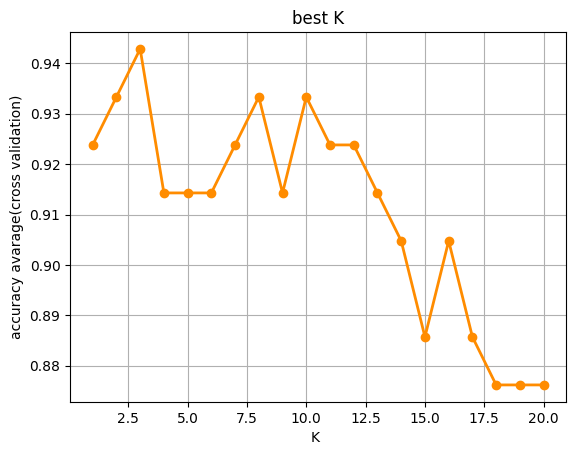

In [36]:
#plot
plt.plot(k_range, cv_scores, "o-",  color = "darkorange" , linewidth = 2)
plt.xlabel("K ")
plt.ylabel("accuracy avarage(cross validation)")
plt.title("best K")
plt.grid(True)
plt.show()

In [37]:
best_k = k_range[np.argmax(cv_scores)]
print(f"best k: {best_k} accuracy {max(cv_scores):.3f}")

best k: 3 accuracy 0.943
